In [1]:
# Description: This program uses an artificial recurrent neural network called Long Short Term Memory (LSTM) to predict 
#the closing stock price of a corporation (Apple Inc.) using the past 60 day stock price.

In [2]:
#Import the libraries
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, GRU
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [3]:
#Get the stock quote 
dataset = web.DataReader('AMZN', data_source='yahoo', start='2012-01-01', end='2020-11-24') 
#Show the data 
data=dataset

In [4]:
y_data=dataset.filter(['Close']).values
y_test=y_data
y_data

array([[ 179.02999878],
       [ 177.50999451],
       [ 177.61000061],
       ...,
       [3099.39990234],
       [3098.38989258],
       [3118.06005859]])

C:\Users\himal\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\converter.py:103: FutureWarning: Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()
  warnings.warn(msg, FutureWarning)


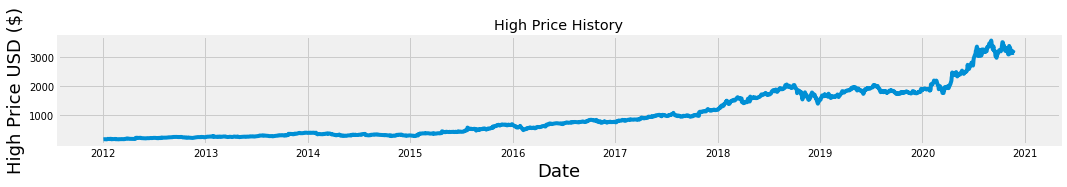

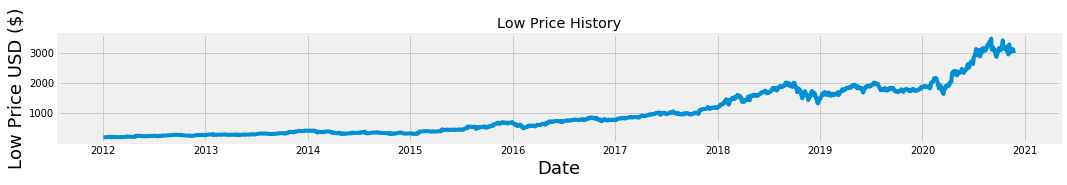

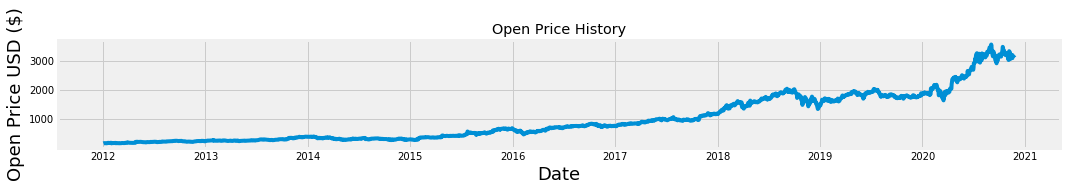

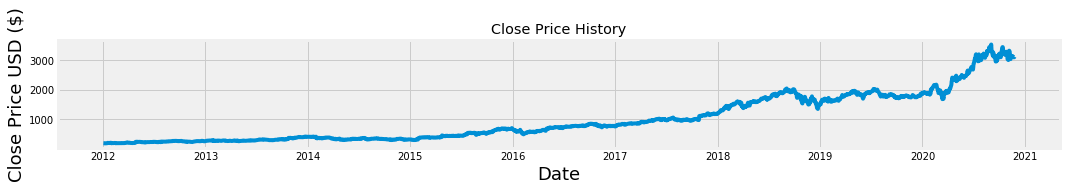

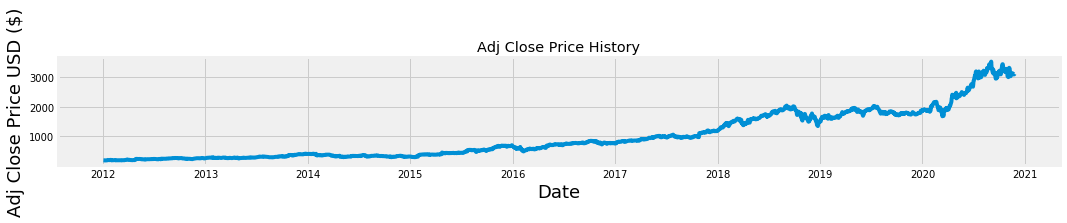

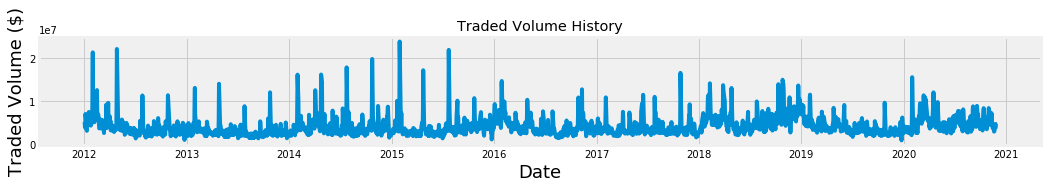

In [5]:
#Visualize the closing price history
plt.figure(figsize=(16,2))
plt.title('High Price History')
plt.plot(dataset['High'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('High Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Low Price History')
plt.plot(dataset['Low'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Low Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Open Price History')
plt.plot(dataset['Open'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Open Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Close Price History')
plt.plot(dataset['Close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Adj Close Price History')
plt.plot(dataset['Adj Close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Adj Close Price USD ($)',fontsize=18)
plt.show()
plt.figure(figsize=(16,2))
plt.title('Traded Volume History')
plt.plot(dataset['Volume'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Traded Volume ($)',fontsize=18)
plt.show()

In [6]:
# Converting the dataframe to a numpy array
dataset = dataset.values

#Get /Compute the number of rows to train the model on
training_data_len = math.ceil( len(dataset) *.8) 
training_data_len

1792

In [7]:
#Scale the all of the data to be values between 0 and 1 
scaler = MinMaxScaler(feature_range=(0, 1)) 
scaled_data = scaler.fit_transform(dataset)
y_data=scaler.fit_transform(y_data)
len(y_data)

2240

In [8]:
#Create the scaled training data set 
train_data = scaled_data[0:training_data_len, : ]
print(len(train_data))
#Split the data into x_train and y_train data sets
x_train=train_data
y_train_data=[]
for i in range(60,len(train_data)):
     y_train_data.append(y_data[i,0])
y_train_data

1792


[0.00854711290330825,
 0.007921276630691705,
 0.006592126004188785,
 0.007071932600562943,
 0.005382180121341645,
 0.005501384864997426,
 0.004750382247331465,
 0.003293082201397575,
 0.0035881200808944302,
 0.004398725070388278,
 0.0037341497571368246,
 0.0028520191930278133,
 0.003713286425943846,
 0.004511972760019911,
 0.00452091288842562,
 0.0041871314209243685,
 0.0036685857839152958,
 0.004291438982150286,
 0.0055103249934031345,
 0.005978212934359503,
 0.015174999421119863,
 0.016679978636094377,
 0.01612566793809298,
 0.01618825338430243,
 0.015949839349621388,
 0.014322672316609546,
 0.01467135096654066,
 0.014295847384022932,
 0.014021672835719055,
 0.015127315704709758,
 0.01542234903683714,
 0.014006771105919712,
 0.01444187706026532,
 0.014343531100433037,
 0.01264483849280603,
 0.01130078613650378,
 0.012570334391178807,
 0.011741849144873535,
 0.01232298022809205,
 0.011715028759656416,
 0.011014688385412634,
 0.011568999083414015,
 0.009923947246221268,
 0.011020649986

In [9]:
x_final=np.empty((1,6))
for i in range(60,len(train_data)):
    x_final=np.concatenate((x_final,x_train[i-60:i]),axis=0)
x_final = np.delete(x_final, (0), axis=0)
x_final.shape
print(x_final)

[[3.64551194e-04 1.07099099e-03 6.16627533e-04 9.23852679e-04
  1.84093006e-01 9.23852679e-04]
 [6.66864256e-04 1.22786969e-03 1.60086125e-03 4.70866468e-04
  1.44675906e-01 4.70866468e-04]
 [0.00000000e+00 6.18459973e-04 6.31451202e-04 5.00669928e-04
  1.27435277e-01 5.00669928e-04]
 ...
 [4.33061655e-01 4.30471637e-01 4.23987383e-01 4.35723833e-01
  1.73115762e-01 4.35723833e-01]
 [4.38094252e-01 4.42005138e-01 4.36734960e-01 4.36316882e-01
  1.16606021e-01 4.36316882e-01]
 [4.32617079e-01 4.32637768e-01 4.30064717e-01 4.31146305e-01
  1.40989258e-01 4.31146305e-01]]


In [10]:
x_train=x_final

In [11]:
#Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train_data)

In [12]:
#Reshape the data into the shape accepted by the LSTM
x_train = np.reshape(x_train, (1732,60,x_train.shape[1]))

In [13]:
x_train[0]

array([[3.64551194e-04, 1.07099099e-03, 6.16627533e-04, 9.23852679e-04,
        1.84093006e-01, 9.23852679e-04],
       [6.66864256e-04, 1.22786969e-03, 1.60086125e-03, 4.70866468e-04,
        1.44675906e-01, 4.70866468e-04],
       [0.00000000e+00, 6.18459973e-04, 6.31451202e-04, 5.00669928e-04,
        1.27435277e-01, 5.00669928e-04],
       [1.89685652e-03, 1.65928038e-03, 1.26290240e-03, 1.99075196e-03,
        2.66687849e-01, 1.99075196e-03],
       [1.81386933e-03, 1.50843671e-03, 2.65327389e-03, 7.83784604e-04,
        1.81746958e-01, 7.83784604e-04],
       [1.22999226e-03, 1.53860729e-03, 2.16116155e-03, 1.01623704e-03,
        1.35126312e-01, 1.01623704e-03],
       [7.46889233e-04, 1.86744539e-03, 1.72833485e-03, 8.85109091e-04,
        9.66885457e-02, 8.85109091e-04],
       [3.67517929e-04, 1.13132753e-03, 1.66311432e-03, 0.00000000e+00,
        1.96062643e-01, 0.00000000e+00],
       [1.63012167e-04, 4.52531014e-04, 5.92910568e-04, 7.42062489e-04,
        1.68541184e-01, 

In [14]:
#Build the LSTM network model
model = Sequential()
model.add(GRU(units=50, return_sequences=True,input_shape=(x_train.shape[1],6)))
model.add(GRU(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

In [15]:
#Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [16]:
#Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

1732/1732 [==============================] - 44s 25ms/step - loss: 5.2687e-04


In [17]:
#Test data set
test_data = scaled_data[training_data_len - 60: , : ]
#Create the x_test and y_test data sets
x_test =  test_data #Get all of the rows from index 1603 to the rest and all of the columns (in this case it's only column 'Close'), so 2003 - 1603 = 400 rows of data
x_final_test=np.empty((1,6))
y_test =  y_test[training_data_len : , : ]
for i in range(60,len(test_data)):
    x_final_test=np.concatenate((x_final_test,test_data[i-60:i]),axis=0)
x_final_test = np.delete(x_final_test, (0), axis=0)
x_test=x_final_test
print(len(y_test))
print(len(x_test))

448
26880


In [18]:
#Convert x_test to a numpy array 
y_test = np.array(y_test)
y_test

array([[1627.57995605],
       [1622.09997559],
       [1619.43994141],
       [1631.56005859],
       [1633.        ],
       [1636.40002441],
       [1641.08996582],
       [1639.82995605],
       [1671.72998047],
       [1696.17004395],
       [1692.43005371],
       [1668.94995117],
       [1625.94995117],
       [1620.80004883],
       [1670.61999512],
       [1673.09997559],
       [1690.81005859],
       [1686.2199707 ],
       [1712.35998535],
       [1742.15002441],
       [1761.84997559],
       [1797.27001953],
       [1819.26000977],
       [1764.77001953],
       [1774.26000977],
       [1783.76000977],
       [1765.69995117],
       [1773.42004395],
       [1780.75      ],
       [1814.18994141],
       [1813.97998047],
       [1820.69995117],
       [1818.85998535],
       [1837.2800293 ],
       [1849.85998535],
       [1835.83996582],
       [1847.32995605],
       [1844.06994629],
       [1843.06005859],
       [1844.86999512],
       [1863.04003906],
       [1864.819

In [19]:
#Reshape the data into the shape accepted by the LSTM
x_test = np.reshape(x_test, (448,60,x_test.shape[1]))
print(x_test)
print(y_test[62])

[[[0.41580911 0.40165446 0.41598606 0.39825722 0.30070773 0.39825722]
  [0.40204505 0.3765058  0.37462758 0.39324158 0.43515069 0.39324158]
  [0.40656491 0.4051661  0.40590064 0.39958039 0.21046973 0.39958039]
  ...
  [0.43809425 0.44200514 0.43673496 0.43631688 0.11660602 0.43631688]
  [0.43261708 0.43263777 0.43006472 0.43114631 0.14098926 0.43114631]
  [0.42995259 0.43216712 0.4310608  0.42676544 0.15071296 0.42676544]]

 [[0.40204505 0.3765058  0.37462758 0.39324158 0.43515069 0.39324158]
  [0.40656491 0.4051661  0.40590064 0.39958039 0.21046973 0.39958039]
  [0.40247479 0.40118686 0.39819577 0.39520852 0.07949144 0.39520852]
  ...
  [0.43261708 0.43263777 0.43006472 0.43114631 0.14098926 0.43114631]
  [0.42995259 0.43216712 0.4310608  0.42676544 0.15071296 0.42676544]
  [0.43146117 0.43097849 0.42309802 0.43261551 0.12189007 0.43261551]]

 [[0.40656491 0.4051661  0.40590064 0.39958039 0.21046973 0.39958039]
  [0.40247479 0.40118686 0.39819577 0.39520852 0.07949144 0.39520852]
  [0

In [20]:
#Getting the models predicted price values
predictions = model.predict(x_test) 
predictions = scaler.inverse_transform(predictions)#Undo scaling
predictions.shape

(448, 1)

In [21]:
#Calculate/Get the value of RMSE
rmse=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse

117.13484578329343

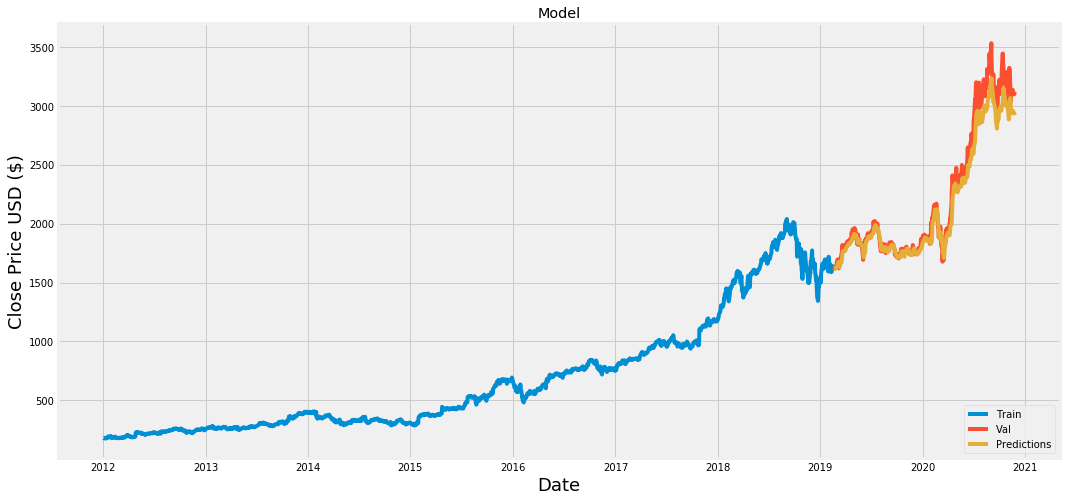

                  Close  predictions
Date                                
2019-02-19  1627.579956  1615.845215
2019-02-20  1622.099976  1616.147705
2019-02-21  1619.439941  1618.809204
2019-02-22  1631.560059  1616.663696
2019-02-25  1633.000000  1620.332153
...                 ...          ...
2020-11-18  3105.459961  2958.048584
2020-11-19  3117.020020  2952.306641
2020-11-20  3099.399902  2943.076660
2020-11-23  3098.389893  2934.147217
2020-11-24  3118.060059  2920.738525

[448 rows x 2 columns]


In [22]:
# #Plot/Create the data for the graph
train = data[:training_data_len]
test = data[training_data_len:]
train=train['Close']
test=test['Close']
valid=pd.DataFrame(test)
valid['predictions']=predictions

#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train)
plt.plot(valid[['Close', 'predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()
print(valid)

In [23]:
#Show the valid and predicted prices
valid

,Close,predictions
Date,,
2019-02-19,1627.579956,1615.845215
2019-02-20,1622.099976,1616.147705
2019-02-21,1619.439941,1618.809204
2019-02-22,1631.560059,1616.663696
2019-02-25,1633.000000,1620.332153
...,...,...
2020-11-18,3105.459961,2958.048584
2020-11-19,3117.020020,2952.306641
2020-11-20,3099.399902,2943.076660


In [24]:
#Get the quote
apple_quote = web.DataReader('AAPL', data_source='yahoo', start='2012-01-01', end='2020-11-24')
#Create a new dataframe
new_df = apple_quote
x_final_test=np.empty((1,6))
x_final_test=np.concatenate((x_final_test,new_df[-60:]),axis=0)
x_final_test = np.delete(x_final_test, (0), axis=0)
test_data=x_final_test
#Scale the data to be values between 0 and 1
test_data_scaled = scaler.transform(test_data)
#Create an empty list
X_test = []
#Append teh past 60 days
X_test=test_data_scaled
#Reshape the data
X_test = np.reshape(X_test, (1,60,X_test.shape[1]))
#Get the predicted scaled price
pred_price = model.predict(X_test)
#undo the scaling 
pred_price = scaler.inverse_transform(pred_price)
print(X_test.shape)
pred_price

(1, 60, 6)


array([[-229.88376]], dtype=float32)

In [25]:
#Get the quote
apple_quote2 = web.DataReader('AAPL', data_source='yahoo', start='2020-11-25', end='2020-11-25')
print(apple_quote2['Close'])

Date
2020-11-24    115.169998
2020-11-25    116.029999
Name: Close, dtype: float64


In [26]:
X_test.shape[0]

1

In [27]:
X_test.shape[1]

60